In [ ]:
!wget -O enron_spam_data.zip https://github.com/MWiechmann/enron_spam_data/raw/refs/heads/master/enron_spam_data.zip

--2026-09-29 09:25:24--  https://github.com/MWiechmann/enron_spam_data/raw/refs/heads/master/enron_spam_data.zip
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/MWiechmann/enron_spam_data/refs/heads/master/enron_spam_data.zip [following]
--2026-09-29 09:25:24--  https://raw.githubusercontent.com/MWiechmann/enron_spam_data/refs/heads/master/enron_spam_data.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15642124 (15M) [application/zip]
Saving to: ‘enron_spam_data.zip’

enron_spam_data.zip 100%[===================>]  14.92M  --.-KB/s    in 0.1s    

2026-09-29 09:25:24 (129 MB/s) - ‘enron_spam

In [ ]:
import zipfile

with zipfile.ZipFile("enron_spam_data.zip", "r") as zip_ref:
    zip_ref.extractall("enron_data")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

os.listdir("enron_data")

['enron_spam_data.csv']

In [ ]:
import pandas as pd

df = pd.read_csv("enron_data/enron_spam_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (33716, 5)


In [ ]:
print("Columns:")
print(df.columns)

Columns:
Index(['Message ID', 'Subject', 'Message', 'Spam/Ham', 'Date'], dtype='object')


In [ ]:
df.head()

,Message ID,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14


In [ ]:
print(df.isnull().sum())

Message ID      0
Subject       289
Message       371
Spam/Ham        0
Date            0
dtype: int64


In [ ]:
print(df["Spam/Ham"].value_counts())

Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64


In [ ]:
df = df[["Subject", "Message", "Spam/Ham"]]

print(df.columns)
print(df.shape)

Index(['Subject', 'Message', 'Spam/Ham'], dtype='object')
(33716, 3)


In [ ]:
df["Subject"] = df["Subject"].fillna("")
df["Message"] = df["Message"].fillna("")

print(df.isnull().sum())

Subject     0
Message     0
Spam/Ham    0
dtype: int64


In [ ]:
df["text"] = df["Subject"] + " " + df["Message"]

print(df[["text", "Spam/Ham"]].head())

                                                text Spam/Ham
0                      christmas tree farm pictures       ham
1  vastar resources , inc . gary , production fro...      ham
2  calpine daily gas nomination - calpine daily g...      ham
3  re : issue fyi - see note below - already done...      ham
4  meter 7268 nov allocation fyi .\n- - - - - - -...      ham


In [ ]:
X = df["text"]
y = df["Spam/Ham"]

print("Input data:", X.shape)
print("Target data:", y.shape)

Input data: (33716,)
Target data: (33716,)


In [8]:
!wget -O enron_spam_data.zip https://github.com/MWiechmann/enron_spam_data/raw/refs/heads/master/enron_spam_data.zip

import zipfile

with zipfile.ZipFile("enron_spam_data.zip", "r") as zip_ref:
    zip_ref.extractall("enron_data")

print("Dataset downloaded and extracted successfully!")

--2026-09-30 07:02:27--  https://github.com/MWiechmann/enron_spam_data/raw/refs/heads/master/enron_spam_data.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/MWiechmann/enron_spam_data/refs/heads/master/enron_spam_data.zip [following]
--2026-09-30 07:02:28--  https://raw.githubusercontent.com/MWiechmann/enron_spam_data/refs/heads/master/enron_spam_data.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15642124 (15M) [application/zip]
Saving to: ‘enron_spam_data.zip’

enron_spam_data.zip 100%[===================>]  14.92M  --.-KB/s    in 0.04s   

2026-09-30 07:02:29 (419 MB/s) - ‘enron_

In [9]:
import pandas as pd

df = pd.read_csv("enron_data/enron_spam_data.csv")

df = df[["Subject", "Message", "Spam/Ham"]]

df["Subject"] = df["Subject"].fillna("")
df["Message"] = df["Message"].fillna("")

df["text"] = df["Subject"] + " " + df["Message"]

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (33716, 4)
                        Subject  \
0  christmas tree farm pictures   
1      vastar resources , inc .   
2  calpine daily gas nomination   
3                    re : issue   
4     meter 7268 nov allocation   

                                             Message Spam/Ham  \
0                                                         ham   
1  gary , production from the high island larger ...      ham   
2             - calpine daily gas nomination 1 . doc      ham   
3  fyi - see note below - already done .\nstella\...      ham   
4  fyi .\n- - - - - - - - - - - - - - - - - - - -...      ham   

                                                text  
0                      christmas tree farm pictures   
1  vastar resources , inc . gary , production fro...  
2  calpine daily gas nomination - calpine daily g...  
3  re : issue fyi - see note below - already done...  
4  meter 7268 nov allocation fyi .\n- - - - - - -...  


In [10]:
X = df["text"]
y = df["Spam/Ham"].map({"ham": 0, "spam": 1})

print("Input data:", X.shape)
print("Target data:", y.shape)

Input data: (33716,)
Target data: (33716,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 26972
Testing samples: 6744


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=50000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (26972, 50000)
Testing TF-IDF shape: (6744, 50000)


In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [14]:
y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")

Predictions completed!


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9900652431791221
Precision: 0.9827981651376146
Recall   : 0.997962154294032
F1 Score : 0.9903221146901632


In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       1.00      0.98      0.99      3309
        Spam       0.98      1.00      0.99      3435

    accuracy                           0.99      6744
   macro avg       0.99      0.99      0.99      6744
weighted avg       0.99      0.99      0.99      6744



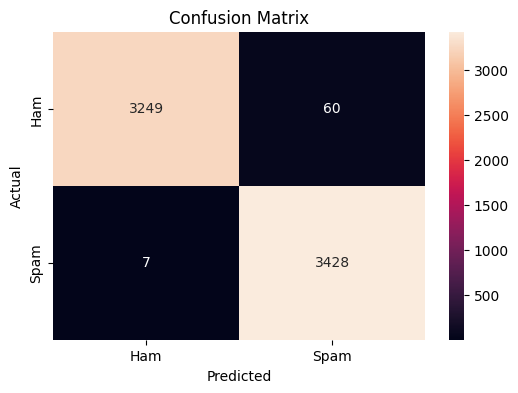

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [18]:
new_email = [
    "Congratulations! You have won a free iPhone. Click here to claim your prize!"
]

new_email_tfidf = vectorizer.transform(new_email)

prediction = model.predict(new_email_tfidf)

if prediction[0] == 1:
    print("Prediction: SPAM")
else:
    print("Prediction: HAM")

Prediction: SPAM


In [19]:
new_email = [
    "Hi, please send me the project report by tomorrow."
]

new_email_tfidf = vectorizer.transform(new_email)

prediction = model.predict(new_email_tfidf)

if prediction[0] == 1:
    print("Prediction: SPAM")
else:
    print("Prediction: HAM")

Prediction: HAM


In [20]:
import joblib

joblib.dump(model, "spam_ham_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [21]:
import os

print(os.listdir())

['.config', 'enron_spam_data.zip', 'enron_data', 'spam_ham_model.pkl', 'tfidf_vectorizer.pkl', 'sample_data']


In [22]:
import joblib

loaded_model = joblib.load("spam_ham_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

test_email = ["Congratulations! You have won a free prize!"]

test_email_tfidf = loaded_vectorizer.transform(test_email)
prediction = loaded_model.predict(test_email_tfidf)

if prediction[0] == 1:
    print("Prediction: SPAM")
else:
    print("Prediction: HAM")

Prediction: SPAM


In [23]:
test_email = [
    "Your bank account has been blocked. Click this link immediately to verify your account."
]

test_email_tfidf = loaded_vectorizer.transform(test_email)
prediction = loaded_model.predict(test_email_tfidf)

if prediction[0] == 1:
    print("Prediction: SPAM")
else:
    print("Prediction: HAM")

Prediction: SPAM


In [25]:
test_email = [
    "Hi Kavin, please send me the project report by tomorrow morning."
]

test_email_tfidf = loaded_vectorizer.transform(test_email)
prediction = loaded_model.predict(test_email_tfidf)

if prediction[0] == 1:
    print("Prediction: SPAM")
else:
    print("Prediction: HAM")

Prediction: HAM


In [26]:
test_email = [
    "Limited time offer! Get 90% discount today. Click here to claim your offer!"
]

test_email_tfidf = loaded_vectorizer.transform(test_email)
prediction = loaded_model.predict(test_email_tfidf)

if prediction[0] == 1:
    print("Prediction: SPAM")
else:
    print("Prediction: HAM")

Prediction: SPAM


In [27]:
%%writefile README.md

# Spam-Ham Email Classification using Machine Learning

## Project Description

This project uses Machine Learning to classify emails as Spam or Ham (legitimate).

The Enron Spam dataset is used to train and evaluate the model.

## Technologies Used

- Python
- Pandas
- Scikit-learn
- TF-IDF Vectorization
- Logistic Regression
- Matplotlib
- Seaborn
- Joblib
- Google Colab

## Dataset

Enron Spam Dataset:
https://github.com/MWiechmann/enron_spam_data

The dataset contains email subjects, messages, and their Spam/Ham labels.

## Project Workflow

1. Load the dataset
2. Handle missing values
3. Combine email Subject and Message
4. Split the data into training and testing sets
5. Convert text into numerical features using TF-IDF
6. Train a Logistic Regression model
7. Predict Spam/Ham emails
8. Evaluate the model using performance metrics
9. Test the model with new emails
10. Save the trained model and TF-IDF vectorizer

## Model

Logistic Regression is used for classification.

TF-IDF (Term Frequency-Inverse Document Frequency) is used to convert email text into numerical features.

## Evaluation Results

- Accuracy: 99.01%
- Precision: 98.28%
- Recall: 99.80%
- F1 Score: 99.03%

## Testing

The trained model was tested with new emails and successfully classified example emails as Spam or Ham.

## Saved Files

- `spam_ham_model.pkl` - trained machine learning model
- `tfidf_vectorizer.pkl` - trained TF-IDF vectorizer
- `.ipynb` - Google Colab notebook containing the complete implementation

## How to Run

1. Download or clone this repository.
2. Open the notebook in Google Colab or Jupyter Notebook.
3. Install the required Python libraries.
4. Run the notebook cells from top to bottom.
5. Enter a new email to test the Spam/Ham prediction.

Writing README.md


In [28]:
%%writefile requirements.txt

pandas
scikit-learn
matplotlib
seaborn
joblib

Writing requirements.txt


In [29]:
import os
print(os.listdir())

['.config', 'enron_spam_data.zip', 'enron_data', 'spam_ham_model.pkl', 'tfidf_vectorizer.pkl', 'requirements.txt', 'README.md', 'sample_data']
